# Διάβασμα της φωτογραφίας


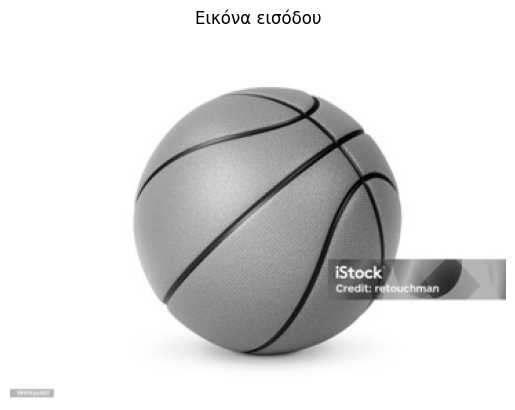

(267, 360)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# Διαδρομή του αρχείου
filename = "basketball_large.png"

# 1. Ανάγνωση εικόνας μέσω PIL
s=4
img = Image.open(fp=filename).convert("L")
img_resized = img.resize((img.width // s, img.height // s), resample=Image.BICUBIC)
input_array = np.array(img_resized).astype(float) / 255.0

plt.imshow(input_array, cmap='gray')
plt.title("Εικόνα εισόδου")
plt.axis('off')
plt.show()



# Συναρτήσεις

In [ ]:
def fir_conv(
    in_img_array: np.ndarray,
    h: np.ndarray,
    in_origin: np.ndarray = None,
    mask_origin: np.ndarray = None
) -> tuple[np.ndarray, np.ndarray]:

    H_img, W_img = in_img_array.shape
    H_mask, W_mask = h.shape

    # Αν δεν δόθηκαν origins, ορίζονται στο (0,0)
    if in_origin is None:
        in_origin = np.array([0, 0])
    if mask_origin is None:
        mask_origin = np.array([0, 0])

    # Υπολογισμός zero-padding
    pad_top = mask_origin[0]
    pad_bottom = H_mask - mask_origin[0] - 1
    pad_left = mask_origin[1]
    pad_right = W_mask - mask_origin[1] - 1

    # Επέκταση εικόνας με μηδενικά
    padded_img = np.pad(
        in_img_array,
        pad_width=((pad_top, pad_bottom), (pad_left, pad_right)),
        mode='constant',
        constant_values=0
    )

    # Εξόδου ίδιο μέγεθος με είσοδο
    out_img_array = np.zeros_like(in_img_array)

    # Συνέλιξη
    for i in range(H_img):
        for j in range(W_img):
            window = padded_img[i:i + H_mask, j:j + W_mask]
            out_img_array[i, j] = np.sum(window * h)

    # Υπολογισμός out_origin μόνο αν δόθηκαν τα in_origin και mask_origin
    out_origin = in_origin + mask_origin if in_origin is not None and mask_origin is not None else None

    return out_img_array, out_origin

In [ ]:
def sobel_edge(
    in_img_array: np.ndarray,
    thres: float
) -> np.ndarray:
    sobel_x = np.array([
        [-1, 0, 1],
        [-2, 0, 2],
        [-1, 0, 1]
    ], dtype=float)

    sobel_y = np.array([
        [1, 2, 1],
        [0, 0, 0],
        [-1, -2, -1]
    ], dtype=float)

    gx, _ = fir_conv(in_img_array, sobel_x, np.array([0, 0]), np.array([1, 1]))
    gy, _ = fir_conv(in_img_array, sobel_y, np.array([0, 0]), np.array([1, 1]))

    grad_mag = np.sqrt(gx**2 + gy**2)
    out_img_array = (grad_mag > thres).astype(int)
    return out_img_array

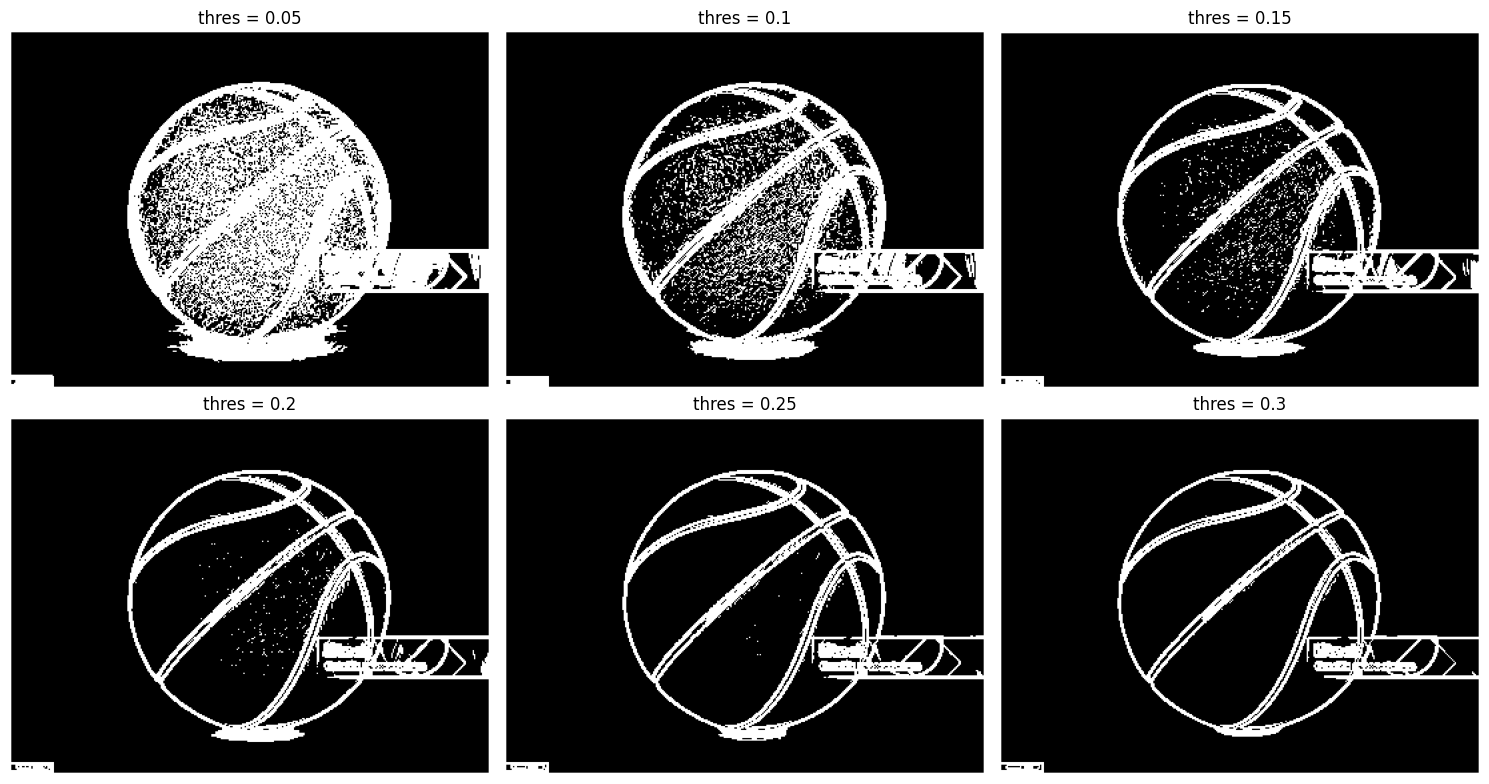

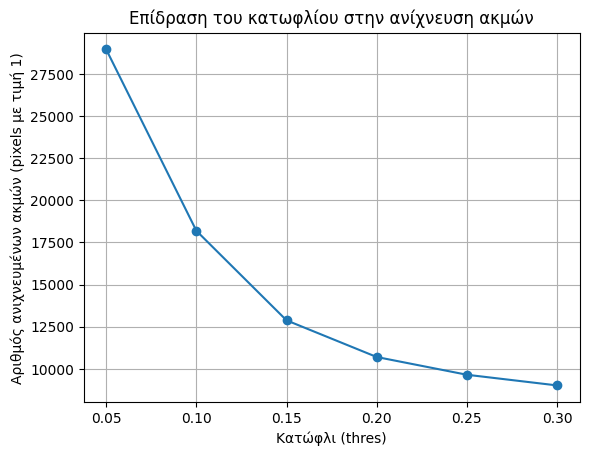

In [ ]:
# Τιμές κατωφλίου για δοκιμή
thres_values = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3]
edge_counts = []


# Εφαρμογή sobel_edge για κάθε thres
plt.figure(figsize=(15, 8))
for idx, thres in enumerate(thres_values):
    edges = sobel_edge(input_array, thres)
    edge_counts.append(np.sum(edges))

    # Εμφάνιση εικόνας ακμών
    plt.subplot(2, 3, idx + 1)
    plt.imshow(edges, cmap="gray")
    plt.title(f"thres = {thres}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Γράφημα μετρήσεων
plt.figure()
plt.plot(thres_values, edge_counts, marker='o')
plt.xlabel("Κατώφλι (thres)")
plt.ylabel("Αριθμός ανιχνευμένων ακμών (pixels με τιμή 1)")
plt.title("Επίδραση του κατωφλίου στην ανίχνευση ακμών")
plt.grid(True)
plt.show()

In [ ]:

import numpy as np
from scipy.ndimage import gaussian_filter

def log_edge(
    in_img_array: np.ndarray,
    log_kernel: np.ndarray = None,
    apply_gaussian: bool = True,
    gaussian_sigma: float = 1.0,
    min_abs_diff: float = 0.02,
    required_opposite_signs: int = 3
) -> np.ndarray:
    """
    Παράμετροι:
    - log_kernel: Προσαρμοσμένος LoG πυρήνας (αν δεν δοθεί, χρησιμοποιείται default 5x5)
    - apply_gaussian: Εφαρμόζει προ-επεξεργασία Gaussian blur
    - gaussian_sigma: Τυπική απόκλιση για Gaussian
    - min_abs_diff: Ελάχιστη διαφορά τιμών για να θεωρηθεί zero-crossing έγκυρο
    - required_opposite_signs: Πλήθος απαιτούμενων αντίθετων πρόσημων γειτόνων
    """

    # Αν δεν δοθεί μάσκα, χρησιμοποιούμε default Mexican Hat 5x5
    if log_kernel is None:
        log_kernel = np.array([
            [0, 0, -1, 0, 0],
            [0, -1, -2, -1, 0],
            [-1, -2, 16, -2, -1],
            [0, -1, -2, -1, 0],
            [0, 0, -1, 0, 0]
        ], dtype=float)

    # Εφαρμογή Gaussian blur (προαιρετική)
    if apply_gaussian:
        in_img_array = gaussian_filter(in_img_array, sigma=gaussian_sigma)

    # Συνέλιξη με LoG μάσκα
    log_response, _ = fir_conv(
        in_img_array,
        log_kernel,
        in_origin=np.array([0, 0]),
        mask_origin=np.array([log_kernel.shape[0] // 2, log_kernel.shape[1] // 2])
    )

    H, W = log_response.shape
    out_img_array = np.zeros((H, W), dtype=int)  # Δυαδική εικόνα εξόδου

    # Διάσχιση κάθε pixel (εκτός ορίων)
    for i in range(1, H - 1):
        for j in range(1, W - 1):
            center = log_response[i, j]
            patch = log_response[i - 1:i + 2, j - 1:j + 2].flatten()

            # Ελέγχει αν υπάρχει αλλαγή πρόσημου στο 3x3 παράθυρο
            if np.any(patch * center < 0):
                # Πόσοι γείτονες έχουν αντίθετο πρόσημο και διαφορά μεγαλύτερη από το κατώφλι
                opposite = [
                    (n * center < 0 and abs(n - center) > min_abs_diff)
                    for n in patch if n != center
                ]
                # Αν αρκετοί γείτονες έχουν τέτοια χαρακτηριστικά, θεωρείται ακμή
                if np.sum(opposite) >= required_opposite_signs:
                    out_img_array[i, j] = 1

    return out_img_array


(np.float64(-0.5), np.float64(359.5), np.float64(266.5), np.float64(-0.5))

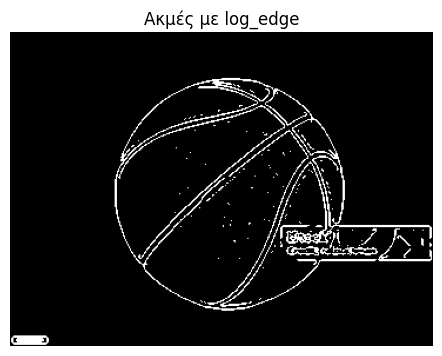

In [ ]:
edges = log_edge(
    in_img_array=input_array,
    gaussian_sigma=1,
    min_abs_diff=0.1,
    required_opposite_signs=3
)

# Σύγκριση εικόνων
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(edges, cmap="gray")
plt.title("Ακμές με log_edge")
plt.axis("off")

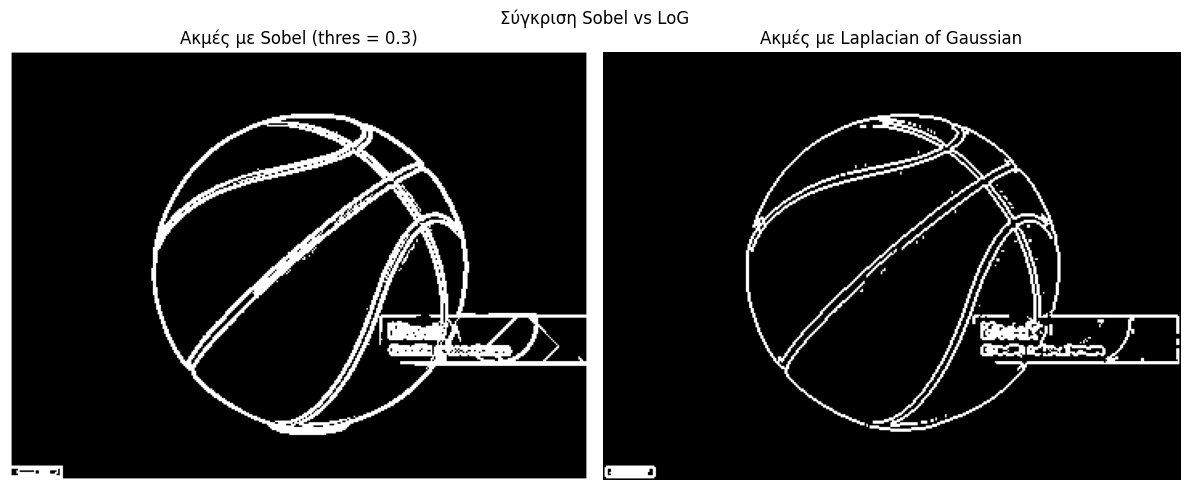

In [ ]:
sobel_result = sobel_edge(input_array, 0.3)
log_result = log_edge(
    in_img_array=input_array,
    gaussian_sigma=1,
    min_abs_diff=0.2,
    required_opposite_signs=2
)

# Σύγκριση εικόνων
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(sobel_result, cmap="gray")
plt.title("Ακμές με Sobel (thres = 0.3)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(log_result, cmap="gray")
plt.title("Ακμές με Laplacian of Gaussian")
plt.axis("off")

plt.suptitle("Σύγκριση Sobel vs LoG")
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from matplotlib.patches import Circle
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
import cv2

def circ_hough_with_votes(in_img_array, R_max, dim, V_min):
    N1, N2 = in_img_array.shape  # Διαστάσεις εικόνας

    # Διαστάσεις του συσσωρευτή: K×L θέσεις κέντρων και M επίπεδα ακτίνας
    K, L, M = dim
    accumulator = np.zeros((K, L, M), dtype=int)  # Hough accumulator 3D

    # Ορίζουμε εύρος πιθανών τιμών για κέντρο a, b (σε normalized grid)
    a_range = np.linspace(0, N1 - 1, K)
    b_range = np.linspace(0, N2 - 1, L)

    # Εύρος ακτίνας: από 10% της εικόνας έως R_max
    R_min = max(5, int(0.1 * min(N1, N2)))
    r_range = np.linspace(R_min, R_max, M)

    # Λίστα με όλα τα pixel που είναι ακμές (τιμή 1)
    edge_points = np.argwhere(in_img_array == 1)

    # Διακριτοποίηση κύκλου (γωνίες για ψηφιοποίηση)
    theta = np.linspace(0, 2 * np.pi, 60, endpoint=False)

    # Για κάθε ακμιακό σημείο, υποθέτουμε όλους τους πιθανούς κύκλους που το περιέχουν
    for (row, col) in edge_points:
        for r_idx, r in enumerate(r_range):
            # Παράγουμε σημεία στον κύκλο γύρω από το (row, col)
            y_vals = row - r * np.sin(theta)
            x_vals = col - r * np.cos(theta)

            # Κανονικοποίηση των κέντρων στο πλέγμα του accumulator
            a_idx = np.round((y_vals / (N1 - 1)) * (K - 1)).astype(int)
            b_idx = np.round((x_vals / (N2 - 1)) * (L - 1)).astype(int)

            # Φιλτράρισμα έγκυρων συντεταγμένων (εντός εικόνας)
            valid = (a_idx >= 0) & (a_idx < K) & (b_idx >= 0) & (b_idx < L)

            # Αυξάνουμε τις ψήφους για τα υποψήφια κέντρα
            for ai, bi in zip(a_idx[valid], b_idx[valid]):
                accumulator[ai, bi, r_idx] += 1

    # Κατώφλι ψήφων (σχετικό με μέγιστο του accumulator)
    V_thresh = max(V_min, int(0.8 * np.max(accumulator)))

    centers, radii, votes = [], [], []

    # Εξαγωγή τοπικών μέγιστων που ξεπερνούν το κατώφλι
    for a_idx in range(K):
        for b_idx in range(L):
            for r_idx in range(M):
                vote = accumulator[a_idx, b_idx, r_idx]
                if vote >= V_thresh:
                    y = a_range[a_idx]
                    x = b_range[b_idx]
                    r = r_range[r_idx]
                    centers.append([x, y])
                    radii.append(r)
                    votes.append(vote)

    return np.array(centers), np.array(radii), np.array(votes)



In [ ]:
import numpy as np
from matplotlib.patches import Circle
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
import cv2

# --- Παραγωγή edge map ---
# Ανίχνευση ακμών με Sobel τελεστή και κατώφλι 0.3
sobel_result = sobel_edge(in_img_array=input_array, thres=0.3)

# Διόγκωση (dilation) των ακμών για να ενισχυθούν οι περιοχές ψήφισης στο Hough
dilated_edges = cv2.dilate(
    sobel_result.astype(np.uint8),
    np.ones((3, 3), np.uint8),
    iterations=1
)

# --- Εκτέλεση Hough ---
# Ορισμός διακριτοποίησης του Hough space (κέντρα και ακτίνες)
dim = np.array([120, 120, 40])  # [a_dim, b_dim, r_dim]
R_max = 100                     # Μέγιστη ακτίνα προς ανίχνευση
V_min = 450                       # Κατώφλι ψήφων

# Κλήση της συνάρτησης circ_hough_with_votes με τις παραπάνω παραμέτρους
centers, radii, votes = circ_hough_with_votes(
    dilated_edges, R_max=R_max, dim=dim, V_min=V_min
)

# --- Οπτικοποίηση ---
top_n = 100  # Επιλέγονται το πολύ 100 ισχυρότεροι κύκλοι
if len(votes) > 0:
    sorted_idx = np.argsort(-votes)[:top_n]  # Ταξινόμηση κατά φθίνουσα σειρά ψήφων
    centers = centers[sorted_idx]
    radii = radii[sorted_idx]

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(input_array, cmap='gray', origin='upper')
    height = input_array.shape[0]

    # Σχεδίαση κύκλων πάνω στην εικόνα
    for (x, y), r in zip(centers, radii):
        y_flipped = height - y  # Αντιστροφή για συμβατότητα με matplotlib
        circ = Circle((x, y_flipped), r, color='lime', fill=False, linewidth=2)
        ax.add_patch(circ)

    ax.set_title(f"Hough (Top {top_n} κύκλοι)")
    ax.axis("off")
    plt.tight_layout()
    plt.show()



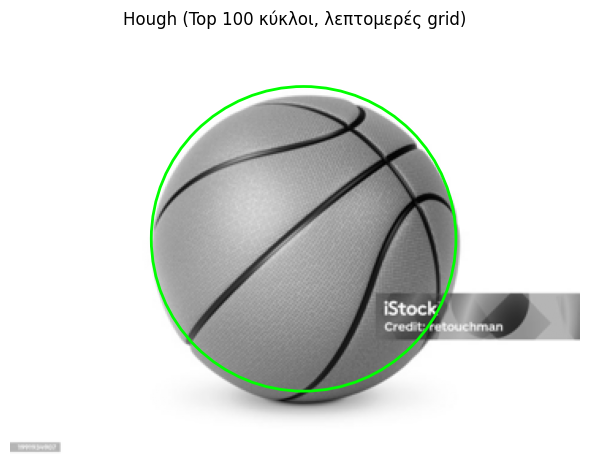

In [ ]:
# --- Παραγωγή edge map ---
log_result = log_edge(
    in_img_array=input_array,
    gaussian_sigma=1,
    min_abs_diff=0.2,
    required_opposite_signs=2
)

dilated_edges = cv2.dilate(log_result.astype(np.uint8), np.ones((3, 3), np.uint8), iterations=1)


# --- Εκτέλεση Hough ---
dim = np.array([100, 100, 40])
R_max = 100
V_min = 450

centers, radii, votes = circ_hough_with_votes(dilated_edges, R_max=R_max, dim=dim, V_min=V_min)

# --- Οπτικοποίηση ---
top_n = 100
if len(votes) > 0:
    sorted_idx = np.argsort(-votes)[:top_n]
    centers = centers[sorted_idx]
    radii = radii[sorted_idx]

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(input_array, cmap='gray', origin='upper')
    height = input_array.shape[0]

    for (x, y), r in zip(centers, radii):
        y_flipped = height - y
        circ = Circle((x, y_flipped), r, color='lime', fill=False, linewidth=2)
        ax.add_patch(circ)

    ax.set_title(f"Hough (Top {top_n} κύκλοι, λεπτομερές grid)")
    ax.axis("off")
    plt.tight_layout()
    plt.show()
